# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

In [1]:
import spacy, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy import sparse
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer 
from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

## Load Data

In [2]:

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

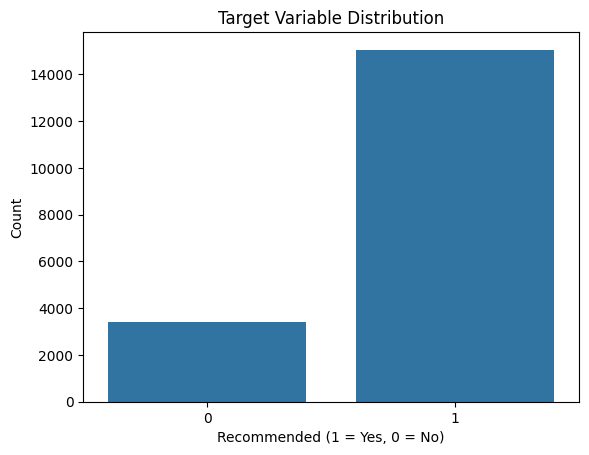

Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64


In [5]:

# Target Distribution
sns.countplot(x='Recommended IND', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Recommended (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

print(df['Recommended IND'].value_counts(normalize=True))


In [6]:
# Numerical Features
df[['Age', 'Positive Feedback Count']].describe()


,Age,Positive Feedback Count
count,18442.000000,18442.000000
mean,43.383635,2.697484
std,12.246264,5.942220
min,18.000000,0.000000
25%,34.000000,0.000000
50%,41.000000,1.000000
75%,52.000000,3.000000
max,99.000000,122.000000


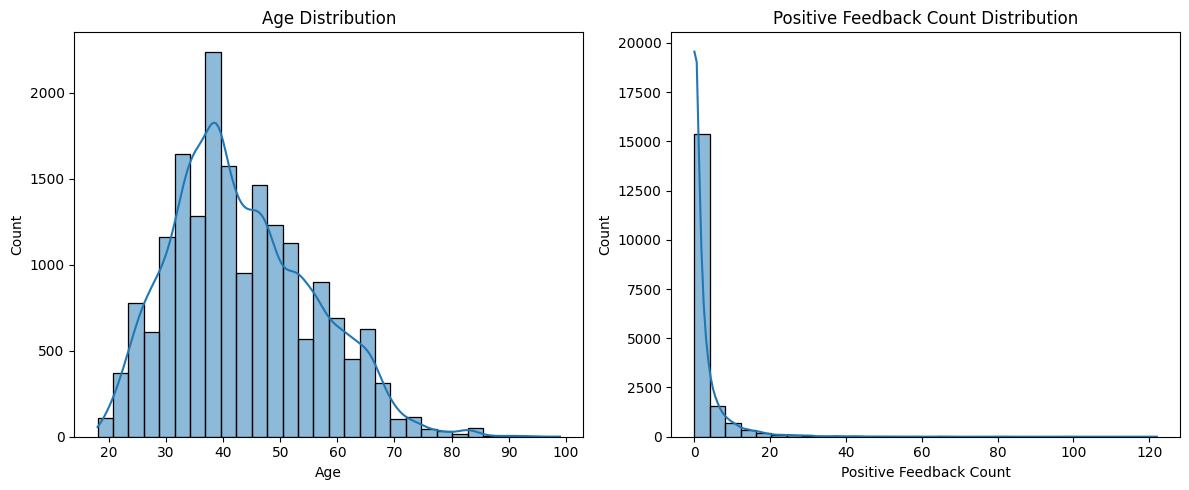

In [7]:

# Numerical features distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First plot - Age
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

# Second plot - Positive Feedback Count
sns.histplot(df['Positive Feedback Count'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Positive Feedback Count Distribution')

plt.tight_layout()
plt.show()




Division Name value counts:
Division Name
General           11664
General Petite     6778
Name: count, dtype: int64

Department Name value counts:
Department Name
Tops        8713
Dresses     5371
Bottoms     3184
Jackets      879
Intimate     188
Trend        107
Name: count, dtype: int64

Class Name value counts:
Class Name
Dresses           5371
Knits             3981
Blouses           2587
Sweaters          1218
Pants             1157
Jeans              970
Fine gauge         927
Skirts             796
Jackets            598
Outerwear          281
Shorts             260
Lounge             188
Trend              107
Casual bottoms       1
Name: count, dtype: int64


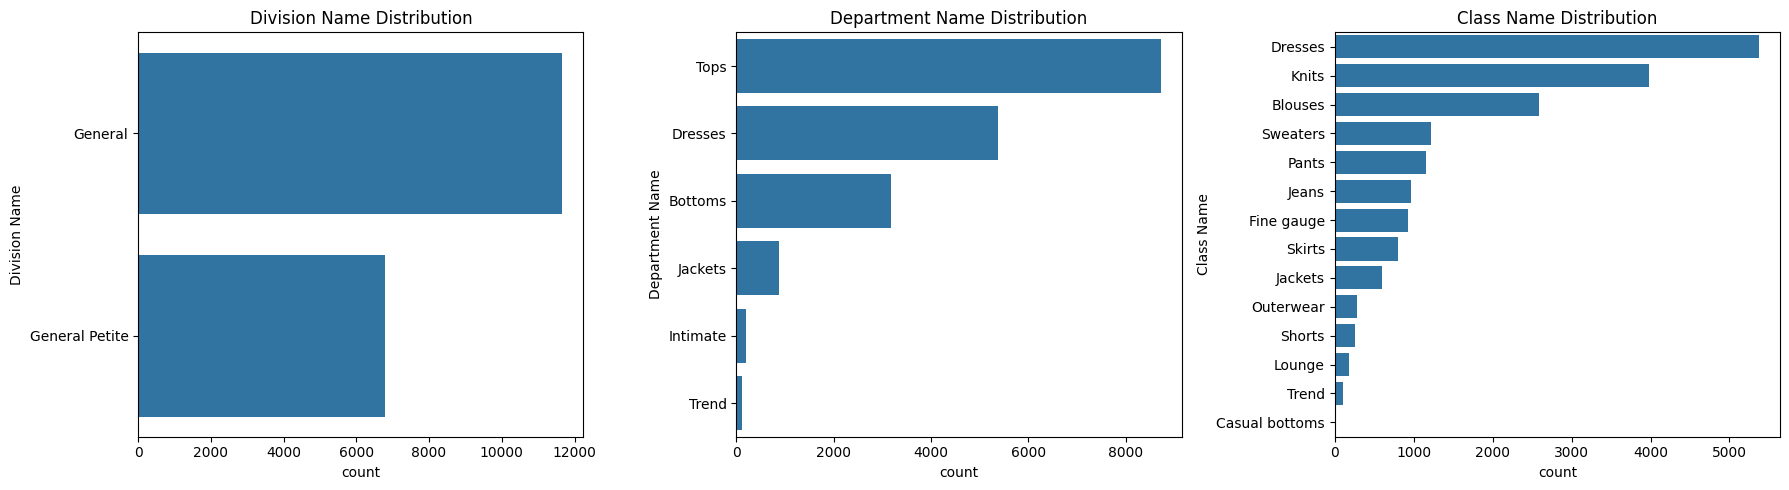

In [8]:

# Categorical data distribution
cols = ['Division Name', 'Department Name', 'Class Name']

fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for i, col in enumerate(cols):
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()



Avg Review Length: 62.4493547337599
Avg Title Length: 3.339171456458085


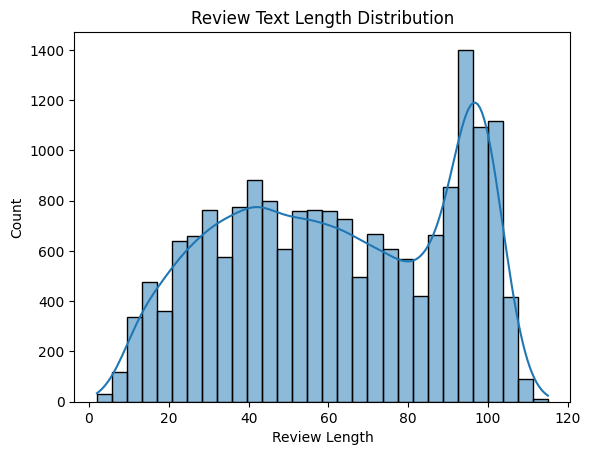

In [9]:
df['Review Length'] = df['Review Text'].apply(lambda x: len(str(x).split()))
df['Title Length'] = df['Title'].apply(lambda x: len(str(x).split()))

print("Avg Review Length:", df['Review Length'].mean())
print("Avg Title Length:", df['Title Length'].mean())

sns.histplot(df['Review Length'], bins=30, kde=True)
plt.title('Review Text Length Distribution')
plt.show()


## Building Pipeline

In [10]:
nlp = spacy.load("en_core_web_sm")  

numeric_feats      = ["Age", "Positive Feedback Count"]
categorical_feats  = ["Clothing ID", "Division Name",
                      "Department Name", "Class Name"]

text_col = "Review Text" 

num_transform = StandardScaler()
cat_transform = OneHotEncoder(handle_unknown="ignore", sparse_output=True)


#### Integrate into the ColumnTransformer

In [11]:

from sklearn.linear_model import LogisticRegression
text_pipeline = TfidfVectorizer(max_features=8000,
                                stop_words="english",
                                ngram_range=(1,1))

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf",  text_pipeline, "Review Text"),
        ("num",    StandardScaler(), numeric_feats),
        ("cat",    OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ],
    remainder="drop"
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",   LogisticRegression(
        solver="liblinear",          # stable for L1/L2 on sparse
        penalty="l2",
        C=1.0,
        class_weight="balanced",     # handles your imbalance
        max_iter=5000
    ))
])

## Training Pipeline

In [12]:

pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=8000,
                                                                  stop_words='english'),
                                                  'Review Text'),
                                                 ('num', StandardScaler(),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Clothing ID',
                                                   'Division Name',
                                                   'Department Name',
                                                   'Class Name'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    solver='liblinear'))])

In [13]:
y_pred   = pipeline.predict(X_test)
y_proba  = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba).round(3))

              precision    recall  f1-score   support

           0       0.55      0.83      0.66       327
           1       0.96      0.85      0.90      1518

    accuracy                           0.85      1845
   macro avg       0.76      0.84      0.78      1845
weighted avg       0.89      0.85      0.86      1845

ROC-AUC: 0.916


#### Feature-Importance Visualisations

## Fine-Tuning Pipeline

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform



# Define your grid parameters
param_distributions = {
    # TF-IDF
    "prep__tfidf__max_features": [12000, 15000, 20000],
    "prep__tfidf__min_df": [3, 5, 10],
    "prep__tfidf__max_df": [0.6,  0.8, 0.9],
    "prep__tfidf__ngram_range": [(1,1), (1,2)],

    # Logistic Regression
    "clf__solver": ["liblinear"],    
    "clf__penalty": ["l2", "l1"],
    "clf__C": loguniform(1e-3, 1e2),
}


# Cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=27)

# Grid search setup
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1_macro",          # balanced objective
    refit="f1_macro", 
    cv=cv,
    verbose=2,  
    return_train_score=True  
)



In [18]:
search.fit(X_train, y_train)
print("Best AUC (CV):", search.best_score_)
print("Best params:")
for k, v in search.best_params_.items():
    print("  ", k, "=", v)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END clf__C=0.0013145149779717103, clf__penalty=l2, clf__solver=liblinear, prep__tfidf__max_df=0.6, prep__tfidf__max_features=20000, prep__tfidf__min_df=3, prep__tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END clf__C=0.0013145149779717103, clf__penalty=l2, clf__solver=liblinear, prep__tfidf__max_df=0.6, prep__tfidf__max_features=20000, prep__tfidf__min_df=3, prep__tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END clf__C=0.0013145149779717103, clf__penalty=l2, clf__solver=liblinear, prep__tfidf__max_df=0.6, prep__tfidf__max_features=20000, prep__tfidf__min_df=3, prep__tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END clf__C=0.009110436333975363, clf__penalty=l2, clf__solver=liblinear, prep__tfidf__max_df=0.6, prep__tfidf__max_features=20000, prep__tfidf__min_df=3, prep__tfidf__ngram_range=(1, 2); total time=   1.3s
[CV] END clf__C=0.009110436333975363, clf__penalty=l2, clf__solver=liblinear, prep__tfidf__m

In [21]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

#use search
best_pipe = search.best_estimator_
y_pred  = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba).round(4))
print(classification_report(y_test, y_pred))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Test ROC-AUC: 0.9173
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       327
           1       0.94      0.91      0.92      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.82      0.80      1845
weighted avg       0.89      0.88      0.88      1845

Confusion matrix:
 [[ 242   85]
 [ 140 1378]]
